In [3]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import numpy as np
import seaborn as sns
from enum import Enum
import json
from pathlib import Path


In [4]:
df = pd.read_csv("../../../cluster_results/pegasus/final_final_versions_d54c3e0a/icospheres_of_different_vertex_counts.csv")
benchmark_file_name_template = lambda i: Path(f"../../data/icospheres_of_different_vertex_counts/icospheres_of_different_vertex_counts_{i}.json")

from algo_metadata import algo_metadata


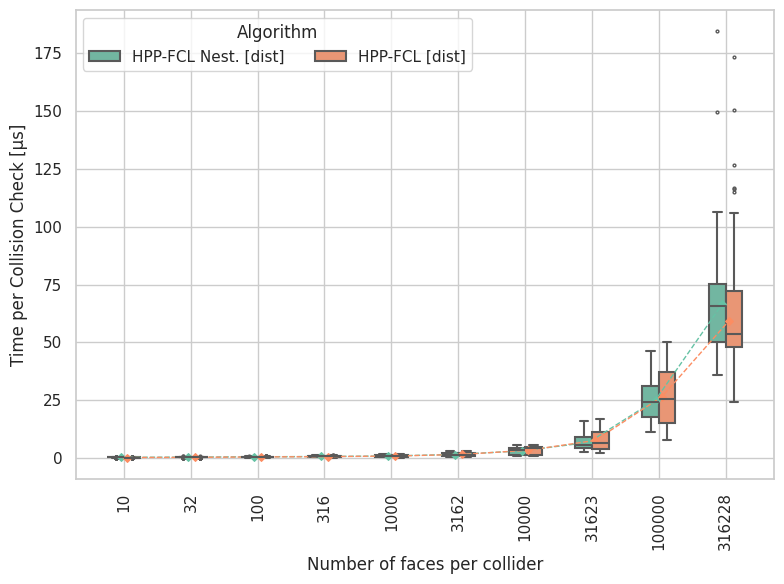

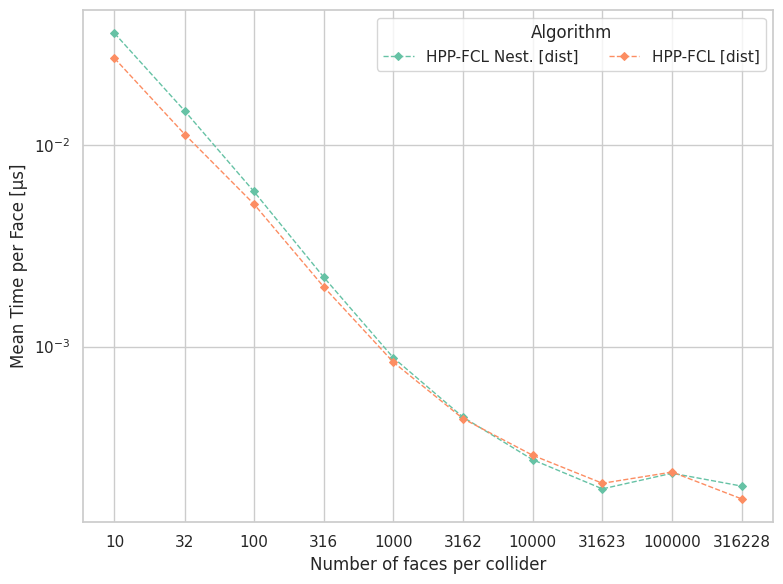

In [10]:
sns.set_theme(style="whitegrid")

N_PER_SECTION = 200
BASE_VERTICES = 1
GROWTH_FACTOR = 4



algos_to_compare = [
    # "FCL distance",
    # "FCL distance linear support",
    # "ncollide_distance",
    # "openGJK distance linear support",
    # "openGJK distance"
    # "distance3d Nesterov (with acceleration)",
    # "distance3d Nesterov",
    "FCL distance",
    "FCL distance defaultGJK",
    # "collision-rs_nasterov_gjk",
    # "collision-rs_distance_gjk"
]


df_part = df.copy(deep=True)
for algo in df_part.columns:
    if algo not in algos_to_compare and algo != "file":
        df_part.drop(algo, axis=1, inplace=True)


# There are N_PER_SECTION rows in the dataframe for each face count and the face count is determined by this formula:
# np.round(10 ** np.arange(1,6, step=0.5))
# Using this info, add a column containing the face counts:
df_part['FaceCount'] = (10 ** (1 + 0.5 * (np.arange(len(df_part)) // N_PER_SECTION))).round().astype(int)
df_long = df_part.melt(id_vars=['file', 'FaceCount'], var_name='Algorithm', value_name='Value')

df_long['PrettyName'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].pretty_name_full)

# add column containing the distance between colliders
def file_to_avg_dist(file_index):
    file_path = benchmark_file_name_template(file_index)
    with open(file_path, "r") as f:
        json_data = json.load(f)
        n_cases_per_test = len(json_data)
        avg_distance = 0
        for case in json_data: avg_distance += case["distance"]
        avg_distance /= n_cases_per_test
    return avg_distance

df_long['AvgDist'] = df_long['file'].map(file_to_avg_dist)
# filter out all entries which exceed min. or max. distances between colliders:
# df_long = df_long[(0.0 < df_long['AvgDist']) & (df_long['AvgDist'] < 0.05)]
# df_long = df_long[(df_long['AvgDist'] < 0.05)]


face_order = sorted(df_long['FaceCount'].unique())

pretty_names = df_long["PrettyName"].unique().tolist()
palette = dict(zip(pretty_names, sns.color_palette('Set2', n_colors=len(pretty_names))))

fig, ax = plt.subplots(figsize=(8, 6))
# Log scales must be set BEFORE plotting so native_scale positioning accounts for them
ax.set_xscale('log')
# ax.set_yscale('log')

sns.boxplot(
    data=df_long, x='FaceCount', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=True, native_scale=True,
    linewidth=1.5,
    fliersize=2, width=0.5, ax=ax
)
sns.pointplot(
    data=df_long, x='FaceCount', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=0.1 if len(algos_to_compare) > 1 else False, native_scale=True,
    estimator=np.mean, errorbar=None,
    markers='D', markersize=4, linestyle='--', linewidth=1,
    ax=ax, legend=False
)

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Number of faces per collider")
ax.set_ylabel("Time per Collision Check [µs]")

# Show the exact face counts as x-tick labels instead of 10^n notation
ax.set_xticks(face_order)
ax.set_xticklabels([str(v) for v in face_order])
ax.tick_params(axis='x', labelrotation=90)


if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()



### Show a time taken per face plot: ###



# Add a column for time per face
df_long['TimePerFace'] = df_long['Value'] / df_long['FaceCount']

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xscale('log')
ax.set_yscale('log')

sns.pointplot(
    data=df_long, x='FaceCount', y='TimePerFace',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=False, native_scale=True,
    estimator=np.mean, errorbar=None,
    markers='D', markersize=4, linestyle='--', linewidth=1,
    ax=ax
)

# sns.boxplot(
#     data=df_long, x='FaceCount', y='TimePerFace',
#     hue='PrettyName', hue_order=pretty_names,
#     palette=palette, dodge=False, native_scale=True,
#     fill=False, linewidth=1.5,
#     fliersize=2, width=0.5, ax=ax
# )

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Number of faces per collider")
ax.set_ylabel("Mean Time per Face [µs]")

ax.set_xticks(face_order)
ax.set_xticklabels([str(v) for v in face_order])
ax.minorticks_off()

if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()

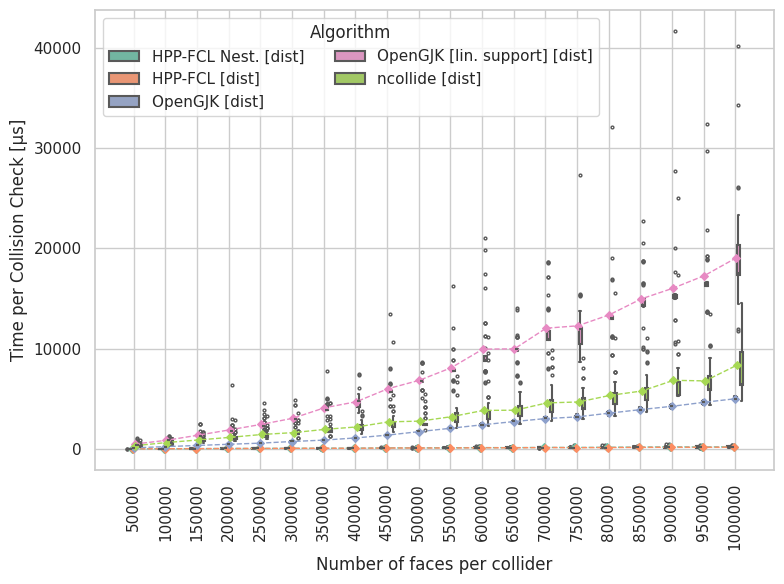

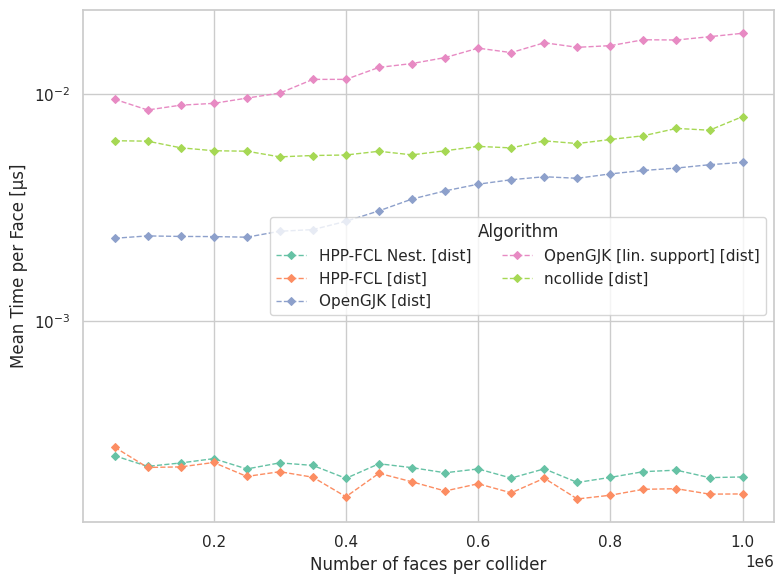

In [8]:
# Same plots, but for the very-high-vertex-count benchmark:

df_high = pd.read_csv("../../../cluster_results/pegasus/final_final_versions_d54c3e0a/icospheres_of_different_high_vertex_counts.csv")
df_high.set_index("file", inplace=True)

sns.set_theme(style="whitegrid")

N_PER_SECTION = 40
FACES_ADDED_PER_STEP = 50_000

algos_to_compare = [
    "FCL distance",
    "FCL distance defaultGJK",
    # "FCL distance linear support",
    "ncollide_distance",
    "openGJK distance linear support",
    "openGJK distance"
]
df_high_part = df_high.copy(deep=True)
for algo in df_high_part.columns:
    if algo not in algos_to_compare:
        df_high_part.drop(algo, axis=1, inplace=True)

# There are N_PER_SECTION rows in the dataframe for each face count and the face count is determined by this formula:
# ((np.arange(df_high_part) // N_PER_SECTION)+1) * FACES_ADDED_PER_STEP
# Using this info, add a column containing the face counts:
df_high_part['FaceCount'] = ((np.arange(len(df_high_part)) // N_PER_SECTION)+1) * FACES_ADDED_PER_STEP
df_high_long = df_high_part.melt(id_vars='FaceCount', var_name='Algorithm', value_name='Value')

df_high_long['PrettyName'] = df_high_long['Algorithm'].map(lambda name: algo_metadata[name].pretty_name_full)

face_order = sorted(df_high_long['FaceCount'].unique())

pretty_names = df_high_long["PrettyName"].unique().tolist()
palette = dict(zip(pretty_names, sns.color_palette('Set2', n_colors=len(pretty_names))))

fig, ax = plt.subplots(figsize=(8, 6))
# Log scales must be set BEFORE plotting so native_scale positioning accounts for them
# ax.set_xscale('log')
# ax.set_yscale('log')

sns.boxplot(
    data=df_high_long, x='FaceCount', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=True, native_scale=True,
    linewidth=1.5,
    fliersize=2, width=0.5, ax=ax
)
sns.pointplot(
    data=df_high_long, x='FaceCount', y='Value',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=0.1 if len(algos_to_compare) > 1 else False, native_scale=True,
    estimator=np.mean, errorbar=None,
    markers='D', markersize=4, linestyle='--', linewidth=1,
    ax=ax, legend=False
)

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Number of faces per collider")
ax.set_ylabel("Time per Collision Check [µs]")

# Show the exact face counts as x-tick labels instead of 10^n notation
ax.set_xticks(face_order)
ax.set_xticklabels([str(v) for v in face_order])
ax.tick_params(axis='x', labelrotation=90)


if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()



### Show a time taken per face plot: ###



# Add a column for time per face
df_high_long['TimePerFace'] = df_high_long['Value'] / df_high_long['FaceCount']

fig, ax = plt.subplots(figsize=(8, 6))

# ax.set_xscale('log')
ax.set_yscale('log')

sns.pointplot(
    data=df_high_long, x='FaceCount', y='TimePerFace',
    hue='PrettyName', hue_order=pretty_names,
    palette=palette, dodge=False, native_scale=True,
    estimator=np.mean, errorbar=None,
    markers='D', markersize=4, linestyle='--', linewidth=1,
    ax=ax
)

# sns.boxplot(
#     data=df_high_long, x='FaceCount', y='TimePerFace',
#     hue='PrettyName', hue_order=pretty_names,
#     palette=palette, dodge=False, native_scale=True,
#     fill=False, linewidth=1.5, legend=False,
#     fliersize=2, width=0.5, ax=ax
# )

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Number of faces per collider")
ax.set_ylabel("Mean Time per Face [µs]")

# ax.set_xticks(face_order)
# ax.set_xticklabels([str(v) for v in face_order])
# ax.minorticks_off()

if len(algos_to_compare) > 1:
    ax.legend(title='Algorithm', loc='best', ncol=2)
else:
    ax.legend().remove()

plt.tight_layout()